[1.6094994e-02 2.9050289e-03 4.1505729e-05 2.5040313e-04 1.9385618e-05
 2.4952140e-04 1.4307036e-04 5.2831069e-06 2.1179354e-05 9.6064759e-05
 1.0683002e-05 3.8149192e-05 1.8908855e-05 1.6030210e-05 3.5304849e-05
 2.4217118e-06]


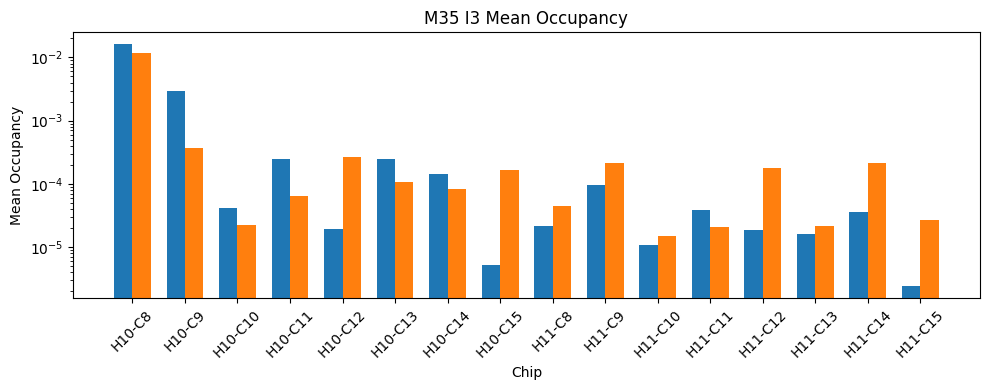

In [6]:
# MODULE 35, Iteration 3, plotting mean occupancy

# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to create file paths for files pre rad in mod35
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_5/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(5)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod35
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_3_PSfullTest_2026-03-13_08-45-57/"
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


#defines root files pre and post rad
root_pre = (
    "PS_16_FNL-10035_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)

#creates lists of mean occupancy values pre and post rad
avgprelist = []
avgpostlist = []

for pre_hybrid in [10, 11]:
    
    for chip in range(8, 16):

        pre_path = make_pre_histpath(pre_hybrid, chip)

        values_pre, _, _ = read_th2(root_pre, pre_path)

        threshold = 0.5

        values_pre = values_pre[values_pre <= threshold]

        avg_pre = np.mean(values_pre)

        avgprelist.append(avg_pre)

for post_hybrid in [2,3]:
    
    for chip in range(8,16):
        
        post_path = make_post_histpath(post_hybrid, chip)

        values_post, _, _ = read_th2(root_post, post_path)

        threshold = 0.5

        values_post = values_post[values_post <= threshold]

        avg_post = np.mean(values_post)
        
        avgpostlist.append(avg_post)



avgprelist = np.array(avgprelist)
avgpostlist = np.array(avgpostlist)

print(avgprelist)
labels = (
    [f"H10-C{chip}" for chip in range(8,16)] +
    [f"H11-C{chip}" for chip in range(8,16)]
)


fig, ax = plt.subplots(figsize=(10,4))

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, avgprelist, width)
ax.bar(x + width/2, avgpostlist, width)

ax.set_ylabel("Mean Occupancy")
ax.set_xlabel("Chip")
ax.set_title("M35 I3 Mean Occupancy")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)

ax.axhline(0, color="black", linewidth=1)

plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



[1.6094994e-02 2.9050289e-03 4.1505729e-05 2.5040313e-04 1.9385618e-05
 2.4952140e-04 1.4307036e-04 5.2831069e-06 2.1179354e-05 9.6064759e-05
 1.0683002e-05 3.8149192e-05 1.8908855e-05 1.6030210e-05 3.5304849e-05
 2.4217118e-06]


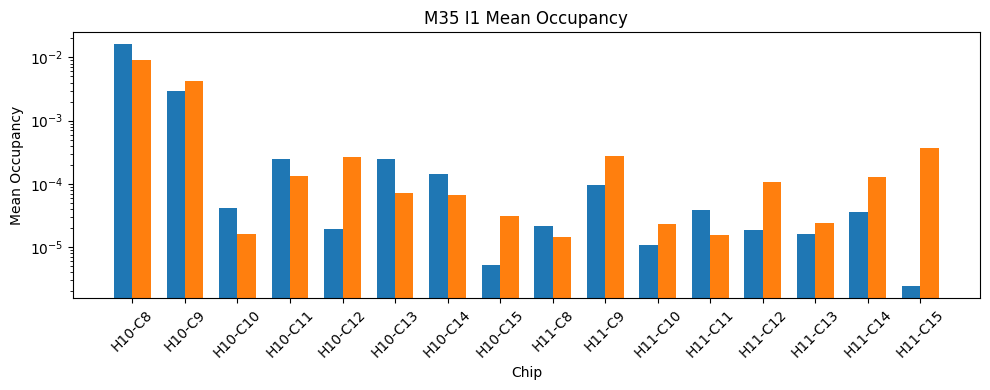

In [7]:
# MODULE 35, Iteration 1, plotting pre rad medians

# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to create file paths for files pre rad
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_5/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(5)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod35
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_1_PSfullTest_2026-03-12_17-23-21/"
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


#defines root files pre and rad
root_pre = (
    "PS_16_FNL-10035_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)


avgprelist = []
avgpostlist = []

for pre_hybrid in [10, 11]:
    
    for chip in range(8, 16):

        pre_path = make_pre_histpath(pre_hybrid, chip)

        values_pre, _, _ = read_th2(root_pre, pre_path)

        threshold = 0.5

        values_pre = values_pre[values_pre <= threshold]

        avg_pre = np.mean(values_pre)

        avgprelist.append(avg_pre)

for post_hybrid in [2,3]:
    
    for chip in range(8,16):
        
        post_path = make_post_histpath(post_hybrid, chip)

        values_post, _, _ = read_th2(root_post, post_path)

        threshold = 0.5

        values_post = values_post[values_post <= threshold]

        avg_post = np.mean(values_post)
        
        avgpostlist.append(avg_post)



avgprelist = np.array(avgprelist)
avgpostlist = np.array(avgpostlist)

print(avgprelist)
labels = (
    [f"H10-C{chip}" for chip in range(8,16)] +
    [f"H11-C{chip}" for chip in range(8,16)]
)


fig, ax = plt.subplots(figsize=(10,4))
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, avgprelist, width)
ax.bar(x + width/2, avgpostlist, width)

ax.set_ylabel("Mean Occupancy")
ax.set_xlabel("Chip")
ax.set_title("M35 I1 Mean Occupancy")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)

ax.axhline(0, color="black", linewidth=1)

plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



[0.009966524, 0.0026516563, 0.00012622002, 6.2427075e-06, 0.0002195704, 8.315624e-06, 8.342983e-05, 0.0031642045, 0.00025189007, 0.00020942447, 7.4406253e-06, 0.0003793804, 4.2764983e-05, 2.5527603e-05, 0.000106154694, 0.0051976615]


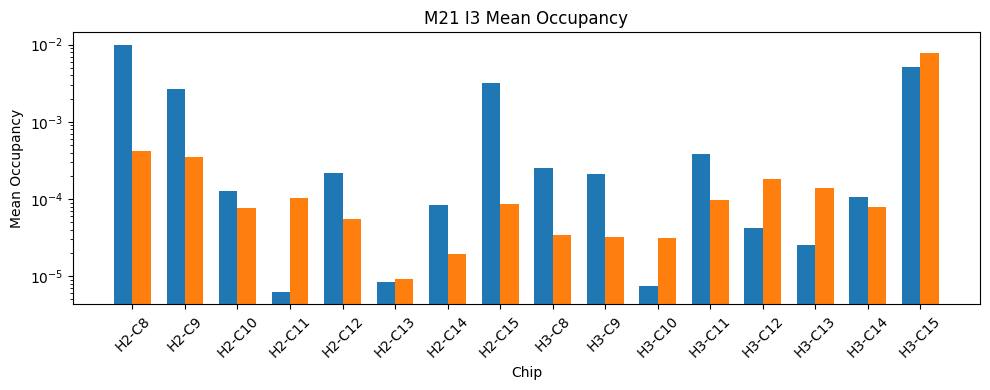

In [8]:
# MODULE 21, Iteration 3, plotting pre rad medians

# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to create file paths for files pre rad
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod35
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_3_PSfullTest_2026-03-13_08-45-57/"
        f"Detector/Board_0/OpticalGroup_2/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(2)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


#defines root files pre and rad
root_pre = (
    "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)


avgprelist = []
avgpostlist = []

for pre_hybrid in [2, 3]:
    
    for chip in range(8, 16):

        pre_path = make_pre_histpath(pre_hybrid, chip)

        values_pre, _, _ = read_th2(root_pre, pre_path)
        
        threshold = 0.5

        values_pre = values_pre[values_pre <= threshold]

        avg_pre = np.mean(values_pre)

        avgprelist.append(avg_pre)

for post_hybrid in [4,5]:
    
    for chip in range(8,16):
        
        post_path = make_post_histpath(post_hybrid, chip)

        values_post, _, _ = read_th2(root_post, post_path)

        threshold = 0.5

        values_post = values_post[values_post <= threshold]

        avg_post = np.mean(values_post)
        
        avgpostlist.append(avg_post)



x = np.arange(len(labels))

ax.bar(x - width/2, avgprelist, width)
ax.bar(x + width/2, avgpostlist, width)

print(avgprelist)
labels = (
    [f"H2-C{chip}" for chip in range(8,16)] +
    [f"H3-C{chip}" for chip in range(8,16)]
)


fig, ax = plt.subplots(figsize=(10,4))
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, avgprelist, width)
ax.bar(x + width/2, avgpostlist, width)

ax.set_ylabel("Mean Occupancy")
ax.set_xlabel("Chip")
ax.set_title("M21 I3 Mean Occupancy")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)


ax.axhline(0, color="black", linewidth=1)

plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



[9.2462804e-03 2.6516563e-03 8.1950966e-06 6.2427075e-06 7.4314034e-06
 8.3156237e-06 1.5886742e-05 2.0092192e-04 6.7481751e-06 7.7347577e-06
 7.4406253e-06 7.0641627e-06 4.2764983e-05 2.5527603e-05 2.1065138e-05
 5.1275520e-03]


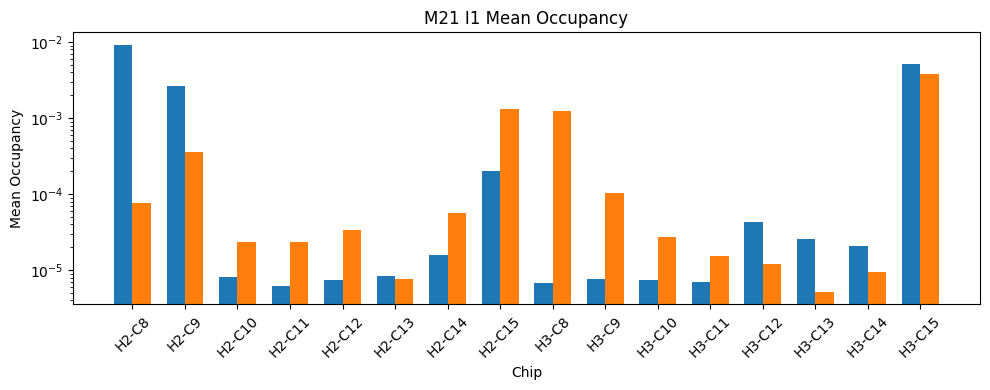

In [33]:
# MODULE 21, Iteration 1, plotting pre rad medians

# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to create file paths for files pre rad
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod35
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_1_PSfullTest_2026-03-12_17-23-21/"
        f"Detector/Board_0/OpticalGroup_2/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(2)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


#defines root files pre and rad
root_pre = (
    "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)

avgprelist = []
avgpostlist = []

for pre_hybrid in [2, 3]:
    
    for chip in range(8, 16):

        pre_path = make_pre_histpath(pre_hybrid, chip)

        values_pre, _, _ = read_th2(root_pre, pre_path)

        values_pre = np.array(values_pre)

        #values_pre = values_pre[:, 3:115]

        threshold = 0.1

        values_pre = values_pre[values_pre <= threshold]

        avg_pre = np.mean(values_pre)

        avgprelist.append(avg_pre)
        

for post_hybrid in [4,5]:
    
    for chip in range(8,16):
        
        post_path = make_post_histpath(post_hybrid, chip)

        values_post, _, _ = read_th2(root_post, post_path)

        values_post = np.array(values_post)

        #values_post = values_post[:, 3:115]

        threshold = 0.1

        values_post = values_post[values_post <= threshold]

        avg_post = np.mean(values_post)
        
        avgpostlist.append(avg_post)



avgprelist = np.array(avgprelist)
avgpostlist = np.array(avgpostlist)

print(avgprelist)
labels = (
    [f"H2-C{chip}" for chip in range(8,16)] +
    [f"H3-C{chip}" for chip in range(8,16)]
)


fig, ax = plt.subplots(figsize=(10,4))
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, avgprelist, width)
ax.bar(x + width/2, avgpostlist, width)

ax.set_ylabel("Mean Occupancy")
ax.set_xlabel("Chip")
ax.set_title("M21 I1 Mean Occupancy")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)

ax.axhline(0, color="black", linewidth=1)

plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



[8.6370371e-03 2.7477932e-03 9.8441187e-06 6.9006942e-06 7.5563280e-06
 9.9979161e-06 1.3648573e-05 2.6812078e-04 7.7746872e-06 8.7665048e-06
 9.2895834e-06 9.0194580e-06 5.6587218e-05 3.4458333e-06 1.0455872e-05
 5.3787674e-03]


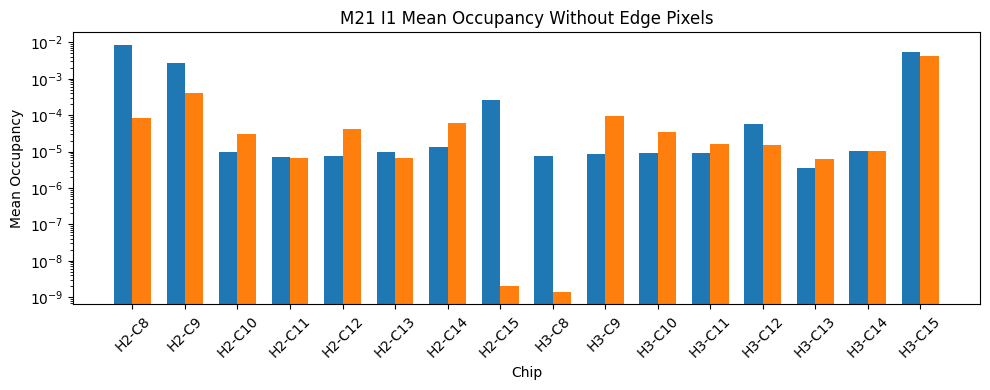

In [42]:
# MODULE 21, Iteration 1, plotting pre rad medians

# import necessary packages
import uproot
import numpy as np
import matplotlib.pyplot as plt


# define fxn to read 2d histogram and return values
def read_th2(root_file, path):

    with uproot.open(root_file) as f:
        hist = f[path]
        values, x_edges, y_edges = hist.to_numpy(flow=False)

    return values, x_edges, y_edges


#define fxn to create file paths for files pre rad
def make_pre_histpath(hybrid, chip):

    return (
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

#define fxn to  create file paths for files post rad in mod35
def make_post_histpath(hybrid, chip):

    return (
        f"Iteration_1_PSfullTest_2026-03-12_17-23-21/"
        f"Detector/Board_0/OpticalGroup_2/"
        f"Hybrid_{hybrid}/"
        f"MPA_{chip}/"
        f"D_B(0)_O(2)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


#defines root files pre and rad
root_pre = (
    "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
)

root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)

avgprelist = []
avgpostlist = []

for pre_hybrid in [2, 3]:
    
    for chip in range(8, 16):

        pre_path = make_pre_histpath(pre_hybrid, chip)

        values_pre, _, _ = read_th2(root_pre, pre_path)

        values_pre = np.array(values_pre)

        values_pre = values_pre[:, 4:115]

        threshold = 0.1

        values_pre = values_pre[values_pre <= threshold]

        avg_pre = np.mean(values_pre)

        avgprelist.append(avg_pre)
        

for post_hybrid in [4,5]:
    
    for chip in range(8,16):
        
        post_path = make_post_histpath(post_hybrid, chip)

        values_post, _, _ = read_th2(root_post, post_path)

        values_post = np.array(values_post)

        values_post = values_post[:, 4:116]

        threshold = 0.1

        values_post = values_post[values_post <= threshold]

        avg_post = np.mean(values_post)
        
        avgpostlist.append(avg_post)



avgprelist = np.array(avgprelist)
avgpostlist = np.array(avgpostlist)

print(avgprelist)
labels = (
    [f"H2-C{chip}" for chip in range(8,16)] +
    [f"H3-C{chip}" for chip in range(8,16)]
)


fig, ax = plt.subplots(figsize=(10,4))
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width/2, avgprelist, width)
ax.bar(x + width/2, avgpostlist, width)

ax.set_ylabel("Mean Occupancy")
ax.set_xlabel("Chip")
ax.set_title("M21 I1 Mean Occupancy Without Edge Pixels")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)

ax.axhline(0, color="black", linewidth=1)

plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

